# Lab 08：系統——roofline、FlashAttention 的演算法、數值格式、資料平行

對應講義：[第 08 課](../lessons/08_systems.md)

這台機器沒有 GPU，所以本實驗量的是 CPU；**形狀**（計算受限 vs 記憶體受限）與**演算法的正確性**是一樣的，數字則小了好幾個數量級。

1. Roofline：矩陣乘法 vs 逐元素運算（式 8.1）
2. Online softmax 與分塊 attention（式 8.2、8.3）：完全相等、記憶體不同
3. 數值格式：fp32、bf16、fp16 的範圍與精度，fp16 的 loss scaling
4. 資料平行：分片梯度的平均 ＝ 全 batch 梯度（式 8.4）；pipeline 的 bubble（式 8.5）
5. Activation checkpointing：用算力換記憶體

CPU 約 2 分鐘。

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
print(f"torch {torch.__version__}, {torch.get_num_threads()} threads")

torch 2.14.0+cu130, 4 threads


## 1. Roofline

$n \times n$ 的 fp32 矩陣乘法：FLOPs $2n^3$、搬動 $3n^2 \times 4$ bytes，強度 $n/6$（fp32）。逐元素相加：強度 $1/12$。

In [2]:
from lm_course.kernels import elementwise_bandwidth, matmul_throughput

mm = [matmul_throughput(n) for n in (16, 32, 64, 128, 256, 512, 1024, 2048)]
ew = [elementwise_bandwidth(n) for n in (10**5, 10**6, 10**7)]
for r in mm:
    print(f"matmul n={r['n']:5d}: {r['gflops']:7.1f} GFLOP/s   intensity {r['intensity']:7.1f} FLOP/byte")
for r in ew:
    print(f"add numel={r['numel']:>9,}: {r['gb_per_s']:6.1f} GB/s  -> {r['gb_per_s'] * r['intensity']:5.2f} GFLOP/s   intensity {r['intensity']:.3f}")

matmul n=   16:     4.4 GFLOP/s   intensity     2.7 FLOP/byte
matmul n=   32:    32.7 GFLOP/s   intensity     5.3 FLOP/byte
matmul n=   64:    53.7 GFLOP/s   intensity    10.7 FLOP/byte
matmul n=  128:   236.2 GFLOP/s   intensity    21.3 FLOP/byte
matmul n=  256:   468.6 GFLOP/s   intensity    42.7 FLOP/byte
matmul n=  512:   566.3 GFLOP/s   intensity    85.3 FLOP/byte
matmul n= 1024:   609.1 GFLOP/s   intensity   170.7 FLOP/byte
matmul n= 2048:   507.9 GFLOP/s   intensity   341.3 FLOP/byte
add numel=  100,000:  166.8 GB/s  -> 13.90 GFLOP/s   intensity 0.083
add numel=1,000,000:   80.6 GB/s  ->  6.72 GFLOP/s   intensity 0.083
add numel=10,000,000:   17.0 GB/s  ->  1.41 GFLOP/s   intensity 0.083


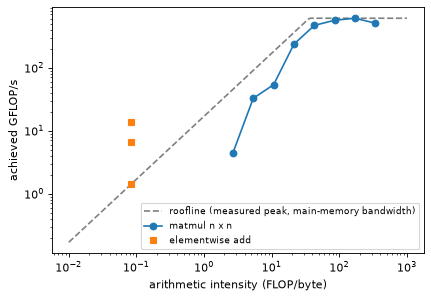

ridge point on this CPU: 36 FLOP/byte  (H100 SXM: about 295)


In [3]:
peak = max(r["gflops"] for r in mm)
bandwidth = ew[-1]["gb_per_s"]  # 10 million elements do not fit in the CPU caches: main-memory bandwidth
xs = np.logspace(-2, 3, 200)
plt.figure(figsize=(6, 4))
plt.loglog(xs, np.minimum(peak, bandwidth * xs), "--", color="gray", label="roofline (measured peak, main-memory bandwidth)")
plt.loglog([r["intensity"] for r in mm], [r["gflops"] for r in mm], "o-", label="matmul n x n")
plt.loglog([r["intensity"] for r in ew], [r["gb_per_s"] * r["intensity"] for r in ew], "s", label="elementwise add")
plt.xlabel("arithmetic intensity (FLOP/byte)")
plt.ylabel("achieved GFLOP/s")
plt.legend(fontsize=8)
plt.show()
print(f"ridge point on this CPU: {peak / bandwidth:.0f} FLOP/byte  (H100 SXM: about 295)")

小矩陣與逐元素運算都在屋頂的斜坡上（記憶體受限）；矩陣變大後強度上升，才碰到平的屋頂（計算受限）。GPU 的屋頂高得多、轉折點也更靠右，所以這個現象更嚴重。

較小的兩個逐元素相加（10 萬、100 萬個元素）甚至跑到屋頂上方：三個陣列加起來才 1.2 MB、12 MB，放得進 CPU 快取，吃到的是快取的頻寬，不是主記憶體的（屋頂的斜率就是用 1,000 萬個元素那一次量的）。記憶體的每一層都有自己的屋頂——FlashAttention 利用的正是 GPU 上「SRAM 快、HBM 慢」這一層。

## 2. Online softmax 與分塊 attention

In [4]:
from lm_course.kernels import attention_score_bytes, online_softmax, tiled_attention
from lm_course.model import attention_reference

x = torch.randn(3, 1000, dtype=torch.float64) * 20
print("online softmax (blocks of 64) == softmax:", torch.allclose(online_softmax(x, 64), x.softmax(-1)))

q, k, v = torch.randn(3, 1, 4, 512, 64).unbind(0)
out, lse = tiled_attention(q, k, v, block_q=64, block_k=64, causal=True)
ref = attention_reference(q, k, v, causal=True)
print(f"tiled attention vs reference: max |diff| = {(out - ref).abs().max():.2e}")

online softmax (blocks of 64) == softmax: True
tiled attention vs reference: max |diff| = 7.75e-07


In [5]:
import torch.nn.functional as F
from lm_course.kernels import time_it

print(f"{'T':>6} {'score matrix here':>18} {'naive':>9} {'tiled (Python)':>15} {'SDPA fused':>11}")
for T in (256, 1024, 2048):
    q, k, v = torch.randn(3, 1, 8, T, 64).unbind(0)
    t_naive = time_it(lambda: attention_reference(q, k, v), repeats=3, warmup=1)
    t_tiled = time_it(lambda: tiled_attention(q, k, v, 128, 128), repeats=3, warmup=1)
    t_sdpa = time_it(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True), repeats=3, warmup=1)
    mb = attention_score_bytes(T, n_head=8, batch_size=1, bytes_per_value=4) / 1e6
    print(f"{T:6d} {mb:15.0f} MB {t_naive * 1e3:7.1f}ms {t_tiled * 1e3:13.1f}ms {t_sdpa * 1e3:9.1f}ms")
print()
print("score matrix of one layer with 32 heads in bf16, one sequence:")
for T in (8192, 131072):
    print(f"  T = {T:6d}: {attention_score_bytes(T, 32, 1) / 1e9:6.1f} GB")

     T  score matrix here     naive  tiled (Python)  SDPA fused
   256               2 MB     0.8ms           1.7ms       0.5ms


  1024              34 MB    27.7ms          12.3ms       3.8ms


  2048             134 MB   108.7ms          42.1ms      11.1ms

score matrix of one layer with 32 heads in bf16, one sequence:
  T =   8192:    4.3 GB
  T = 131072: 1099.5 GB


- 分塊版與參考版的結果相同（差異在浮點誤差內）。
- 即使是用 Python 迴圈寫的分塊版，在 $T \ge 1024$ 時也比 naive 版快：naive 版要寫出、再讀回整張 $T \times T$ 的分數表（$T = 2048$ 時 134 MB，放不進快取），分塊版每一塊都在快取裡算完——和上一節最後說的是同一件事。
- 把整件事寫成一個 fused kernel（PyTorch 的 `scaled_dot_product_attention`；GPU 上就是 FlashAttention）又快了好幾倍。
- naive attention 的分數表隨 $T^2$ 成長：128K context 時一層、一條序列就要上千 GB——不分塊根本放不下。

## 3. 數值格式

In [6]:
for dtype in (torch.float32, torch.bfloat16, torch.float16):
    info = torch.finfo(dtype)
    one_plus = torch.tensor(1.0, dtype=dtype) + torch.tensor(2.0**-9, dtype=dtype)
    print(f"{str(dtype):>15}: max {info.max:.2e}, smallest normal {info.tiny:.2e}, eps {info.eps:.1e}, 1 + 2^-9 = {one_plus.item():.6f}")

values = torch.full((100_000,), 1e-3)
running = {}
for dtype in (torch.bfloat16, torch.float16):
    total, step = torch.zeros((), dtype=dtype), torch.tensor(1e-3, dtype=dtype)
    for _ in range(len(values)):
        total = total + step  # every partial sum is rounded to the low-precision format
    running[dtype] = total.item()
print()
print("sum of 100,000 x 0.001 (exact 100):")
print(f"  fp32                                 {values.sum().item():8.3f}")
print(f"  bf16 running sum                     {running[torch.bfloat16]:8.3f}")
print(f"  fp16 running sum                     {running[torch.float16]:8.3f}")
print(f"  bf16 values, fp32 accumulation       {values.bfloat16().float().sum().item():8.3f}")

  torch.float32: max 3.40e+38, smallest normal 1.18e-38, eps 1.2e-07, 1 + 2^-9 = 1.001953
 torch.bfloat16: max 3.39e+38, smallest normal 1.18e-38, eps 7.8e-03, 1 + 2^-9 = 1.000000
  torch.float16: max 6.55e+04, smallest normal 6.10e-05, eps 9.8e-04, 1 + 2^-9 = 1.001953

sum of 100,000 x 0.001 (exact 100):
  fp32                                  100.000
  bf16 running sum                        0.500
  fp16 running sum                        4.000
  bf16 values, fp32 accumulation         99.945


bf16 的 eps 約 $0.008$：$1 + 2^{-9}$ 還是 1。逐一累加 10 萬個 0.001、每一步的部分和都捨入成 bf16 時，累計到 0.5 之後，0.001 已經小於相鄰兩個 bf16 數間距的一半，加上去等於沒加——總和停在 0.5（fp16 的精度多 3 位，停在 4）。值存成 bf16、但用 fp32 累加，結果就幾乎正確（99.945 的誤差來自 0.001 本身存成 bf16 時的捨入）。這就是為什麼矩陣乘法的累加要用 fp32。

**fp16 的下溢與 loss scaling**：拿一組很小的梯度（例如大模型後段常見的量級）轉成 fp16。

In [7]:
grads = torch.randn(1_000_000) * 1e-6
for scale in (1.0, 2.0**8, 2.0**16):
    as_fp16 = (grads * scale).half()
    zeros = (as_fp16 == 0).float().mean().item()
    recovered = as_fp16.float() / scale
    rel_err = ((recovered - grads).abs().mean() / grads.abs().mean()).item()
    print(f"loss scale {scale:>8.0f}: {zeros:6.1%} of gradients become 0 in fp16, mean relative error {rel_err:.3f}")
print(f"the same gradients in bf16: {(grads.bfloat16() == 0).float().mean().item():.1%} become 0")

loss scale        1:   2.4% of gradients become 0 in fp16, mean relative error 0.019
loss scale      256:   0.0% of gradients become 0 in fp16, mean relative error 0.000
loss scale    65536:   0.0% of gradients become 0 in fp16, mean relative error 0.000
the same gradients in bf16: 0.0% become 0


fp16 的範圍小：$10^{-6}$ 量級的梯度有一部分（這裡 2.4%）直接變成 0，其餘多半落在精度很差的次正規數（平均相對誤差約 2%）；先乘上 $2^8$ 或 $2^{16}$ 再轉就沒問題。bf16 的指數位數和 fp32 一樣，不需要這個技巧（講義 §2.4）。

## 4. 平行化

### 4.1 資料平行：梯度平均 ＝ 全 batch 梯度

In [8]:
from lm_course.kernels import data_parallel_gradients
from lm_course.model import GPT, llama_style_config
from lm_course.training import lm_loss

model = GPT(llama_style_config(vocab_size=512, context_length=64, n_layer=2, n_head=4, d_model=64))
x = torch.randint(0, 512, (16, 64))
y = torch.randint(0, 512, (16, 64))
loss_fn = lambda m, xs, ys: lm_loss(m(xs), ys)

loss_fn(model, x, y).backward()
full = [p.grad.clone() for p in model.parameters()]
for workers in (2, 4, 8):
    dp = data_parallel_gradients(model, loss_fn, x, y, workers)
    diff = max((a - b).abs().max().item() for a, b in zip(full, dp))
    print(f"{workers} workers: max |full-batch grad - averaged grad| = {diff:.1e}")

n_params = sum(p.numel() for p in model.parameters())
print(f"\nring all-reduce traffic per step and GPU ~ 2 x params x 2 bytes: GPT-2 small {2 * 124e6 * 2 / 1e9:.1f} GB, 7B {2 * 7e9 * 2 / 1e9:.0f} GB")

2 workers: max |full-batch grad - averaged grad| = 3.6e-09
4 workers: max |full-batch grad - averaged grad| = 3.6e-09
8 workers: max |full-batch grad - averaged grad| = 4.2e-09

ring all-reduce traffic per step and GPU ~ 2 x params x 2 bytes: GPT-2 small 0.5 GB, 7B 28 GB


### 4.2 ZeRO 與 pipeline bubble

model state per GPU for a 7B model on 8 GPUs (mixed-precision AdamW, 16 bytes/param):
  ZeRO stage 0:  112.0 GB
  ZeRO stage 1:   38.5 GB
  ZeRO stage 2:   26.2 GB
  ZeRO stage 3:   14.0 GB


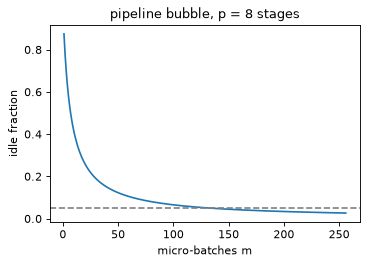

m needed for < 5% bubble with p = 8: 134


In [9]:
from lm_course.scaling import zero_memory_per_gpu

print("model state per GPU for a 7B model on 8 GPUs (mixed-precision AdamW, 16 bytes/param):")
for stage in range(4):
    print(f"  ZeRO stage {stage}: {zero_memory_per_gpu(7e9, 8, stage) / 1e9:6.1f} GB")

stages = 8
micro = np.arange(1, 257)
bubble = (stages - 1) / (micro + stages - 1)
plt.figure(figsize=(5, 3.2))
plt.plot(micro, bubble)
plt.axhline(0.05, color="gray", ls="--")
plt.xlabel("micro-batches m")
plt.ylabel("idle fraction")
plt.title(f"pipeline bubble, p = {stages} stages")
plt.show()
print(f"m needed for < 5% bubble with p = 8: {int(micro[bubble < 0.05][0])}")

## 5. Activation checkpointing

用 Lab 06 的模型大小（4 層、寬 256、context 256），比較一般的 forward／backward 與「每個區塊只存輸入、backward 時重算」：

In [10]:
from torch.utils.checkpoint import checkpoint

from lm_course.artifacts import base_model_config
from lm_course.scaling import saved_activation_bytes

model = GPT(base_model_config())
idx = torch.randint(0, 4096, (16, 256))


class Checkpointed(torch.nn.Module):
    def __init__(self, inner: GPT) -> None:
        super().__init__()
        self.inner = inner

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        m = self.inner
        x = m.token_embedding(idx)
        rope = (m.rope_cos[: idx.shape[1]], m.rope_sin[: idx.shape[1]])
        for layer, block in enumerate(m.blocks):
            x = checkpoint(block, x, rope, layer, None, use_reentrant=False)
        logits = m.lm_head(m.final_norm(x))
        cap = m.config.logit_softcap
        return cap * torch.tanh(logits / cap) if cap else logits


ckpt = Checkpointed(model)
for name, net in [("plain", model), ("checkpointed", ckpt)]:
    saved = saved_activation_bytes(net, idx)
    seconds = time_it(lambda: net(idx).float().logsumexp(-1).mean().backward(), repeats=3, warmup=1)
    print(f"{name:>13}: saved activations {saved / 1e6:7.1f} MB, forward+backward {seconds:.2f}s")
print(f"model state (fp32 AdamW): {model.num_parameters() * 16 / 1e6:.1f} MB")

        plain: saved activations   395.3 MB, forward+backward 0.48s


 checkpointed: saved activations    92.3 MB, forward+backward 0.56s
model state (fp32 AdamW): 83.9 MB


checkpointing 把存下的 activation 大幅減少，代價是 backward 時多跑一次 forward（時間增加）。注意這個小模型的 activation 已經比模型狀態大好幾倍——大 batch、長 context 時更是如此（第 07 課 §2.2）。

## 小結

- 效能由算術強度決定：矩陣乘法可以吃滿算力，逐元素運算只能吃滿頻寬。
- FlashAttention 是精確的；它省的是記憶體與記憶體讀寫。
- bf16 用精度換範圍，fp16 用範圍換精度（所以需要 loss scaling）；累加一定要用高精度。
- 資料平行不改變數學；切分模型狀態、切矩陣、切層，是在記憶體、計算與通訊之間取捨。

下一步：[第 09 課](../lessons/09_inference.md)——推論時的瓶頸完全不同。